# Przygotowanie danych i eksploracyjna analiza danych (EDA)

Celem notebooka jest wstępna analiza danych treningowych pochodzących z zegarka Garmin, ich oczyszczenie oraz przygotowanie do dalszego etapu modelowania predykcyjnego.

Zakres prac obejmuje:
- charakterystykę struktury i jakości danych,
- identyfikację braków danych oraz potencjalnych wartości odstających,
- przygotowanie zbioru danych do procesu uczenia modeli,
- zapis przetworzonego zbioru danych do pliku.

Notebook stanowi etap przygotowawczy do modelowania intensywności treningu, realizowanego w Notebooku 02.

# Import bibliotek i konfiguracja środowiska

W pierwszym kroku zaimportowano biblioteki niezbędne do przeprowadzenia analizy eksploracyjnej danych oraz skonfigurowano ustawienia wizualizacji w celu zapewnienia spójności prezentowanych wyników.

In [1]:
# Biblioteki bazowe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wizualizacji i wyświetlania
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Wyświetlanie Markdown w notebooku via Code
from IPython.display import Markdown, display   

# Wczytanie zbioru danych
Wczytano surowe dane treningowe wyeksportowane z platformy **Garmin Connect** (okres: *27.12.2023–27.01.2026*). 

## Charakterystyka danych wejściowych
Dane wykorzystane w projekcie obejmują **historię aktywności fizycznych autora**. Zbiór danych pochodzi od jednego użytkownika, co ogranicza możliwość generalizacji wyników.

Każda obserwacja odpowiada pojedynczemu treningowi i zawiera informacje dotyczące czasu trwania, parametrów fizjologicznych oraz metadanych opisowych.

In [2]:
df = pd.read_csv('../data/raw/Activities.csv')

N, M = df.shape
display(Markdown(f"Zbiór danych obejmuje **{N} obserwacji** oraz **{M} zmiennych** opisujących aktywności fizyczne, ich czas trwania, parametry fizjologiczne oraz metryki ruchowe."))

# Wyświetlenie pierwszych obserwacji pozwala na wstępną ocenę struktury danych, typów kolumn oraz sposobu zapisu brakujących wartości
df.head()

Zbiór danych obejmuje **1340 obserwacji** oraz **34 zmiennych** opisujących aktywności fizyczne, ich czas trwania, parametry fizjologiczne oraz metryki ruchowe.

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Avg Bike Cadence,Max Bike Cadence,Avg Speed,Max Speed,Total Ascent,Total Descent,Avg Stride Length,Training Stress Score®,Steps,Total Reps,Total Poses,Min Temp,Decompression,Best Lap Time,Number of Laps,Max Temp,Stress Change,Stress Start,Stress End,Avg Stress,Max Stress,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Yoga,2026-01-10 19:00:53,False,Yoga,--,173,00:43:17,92,136,--,--,--,--,--,--,--,0.0,--,--,--,28.0,No,00:43:17,1,31.0,-18,96,78,74,98,00:00:00,00:43:17,--,--
1,Cardio,2026-01-09 16:55:58,False,Boxing,0.00,658,01:03:33,145,179,--,--,--,--,--,--,--,0.0,--,--,--,19.0,No,01:03:33,1,26.0,--,--,--,--,--,00:00:00,01:03:33,-215,254
2,Cardio,2026-01-08 19:56:04,False,Boxing,0.00,798,01:11:37,148,196,--,--,--,--,--,--,--,0.0,--,--,--,19.0,No,01:11:37,1,25.0,--,--,--,--,--,00:00:00,01:11:37,-150,-141
3,Strength Training,2026-01-07 20:29:21,False,Strength,0.00,236,01:01:05,89,113,--,--,--,--,--,--,--,0.0,10,5,1,21.0,No,01:01:05,1,29.0,--,--,--,--,--,01:01:05,01:01:05,--,--
4,Yoga,2026-01-07 12:26:14,False,Yoga,--,83,00:15:58,102,119,--,--,--,--,--,--,--,0.0,--,--,--,28.0,No,00:15:58,1,29.0,90,0,90,88,97,00:00:00,00:15:58,--,--


Na tym etapie nie wprowadzano żadnych modyfikacji danych; celem było wyłącznie rozpoznanie struktury i jakości surowego zbioru.

# Struktura i typy danych

Analiza struktury zbioru (`df.info()`) wykazała, że znaczna część zmiennych zostało wczytanych jako **tekstowe (`object`/`str`)**, mimo że semantycznie reprezentują wartości liczbowe. W kolejnych etapach zostaną one odpowiednio przekształcone do postaci **float**. Eksploracja ujawniła również obecność wartości **'--'**, pełniących funkcję placeholderów braków danych. Na dalszych etapach są one konsekwentnie traktowane jako **NaN**.

W konsekwencji standardowy opis statystyczny (`df.describe()`) nie obejmuje większości istotnych cech. W celu ich charakterystyki zastosowano **df.describe(include=['object', 'string'])**, co pozwoliło ocenić liczność, unikalność oraz najczęściej występujące kategorie.  

Dodatkowo sprawdzono obecność obserwacji zduplikowanych. Analiza (`df.duplicated().sum()`) nie wykazała występowania duplikatów, co jest spójne z faktem, że każda obserwacja odpowiada pojedyncznej aktywności z unikalnym znacznikiem czasowym.

In [3]:
df.info()
df.describe(include=['object', 'string'])
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Activity Type           1340 non-null   str    
 1   Date                    1340 non-null   str    
 2   Favorite                1340 non-null   bool   
 3   Title                   1340 non-null   str    
 4   Distance                1340 non-null   str    
 5   Calories                1340 non-null   str    
 6   Time                    1340 non-null   str    
 7   Avg HR                  1340 non-null   str    
 8   Max HR                  1340 non-null   str    
 9   Avg Bike Cadence        1340 non-null   str    
 10  Max Bike Cadence        1340 non-null   str    
 11  Avg Speed               1340 non-null   str    
 12  Max Speed               1340 non-null   str    
 13  Total Ascent            1340 non-null   str    
 14  Total Descent           1340 non-null   str    
 15

np.int64(0)

# Filtrowanie typów aktywności

Przed dalszą analizą oceniono liczność obserwacji dla poszczególnych typów aktywności. 

Pozwoliło to zidentyfikować kategorie o **marginalnej reprezentacji**, które mogłyby obniżyć stabilność i wiarygodność późniejszego modelowania.

In [4]:
df['Activity Type'].value_counts()

Activity Type
Yoga                            503
Cardio                          294
Strength Training               272
Walking                         204
Other                            36
Cycling                          13
Running                          11
Indoor Cycling                    2
Cross Country Classic Skiing      2
Indoor Running                    1
Stair Stepper                     1
Boxing                            1
Name: count, dtype: int64

## Selekcja typów aktywności

W celu zawężenia analizy do aktywności najbardziej reprezentatywnych i porównywalnych, zbiór danych ograniczono do czterech kategorii: **Cardio**, **Yoga**, **Strength Training** oraz **Walking**.

Rzadkie aktywności odrzucono z powodów **statystycznych** — ich niewielka liczność utrudnia wiarygodne modelowanie i zwiększa ryzyko przeuczenia.  

## Zmiennie specyficzne dla poszczególnych typów aktywności

| Typ aktywności | Zmienne specyficzne | Uzasadnienie |
|----------------|---------------------|--------------|
| **Yoga** | `Avg Stress`, `Stress Change` | Garmin raportuje poziom stresu dla aktywności o charakterze regeneracyjnym. |
| **Strength Training** | `Total Reps`, `Total Poses` | Opisują objętość treningu siłowego, nie występują w innych aktywnościach. |
| **Walking** | `Distance`, `Steps` | Kluczowe cechy opisujące objętość ruchu podczas chodzenia. |
| **Cardio** | - | Garmin nie raportuje dodatkowych metryk unikalnych dla tej kategorii. |


In [5]:
allowed_activities = ['Yoga', 'Cardio', 'Strength Training', 'Walking']

df = df[df['Activity Type'].isin(allowed_activities)].copy()
df['Activity Type'].value_counts()

Activity Type
Yoga                 503
Cardio               294
Strength Training    272
Walking              204
Name: count, dtype: int64

# Redukcja liczby zmiennych

Zbiór danych zawierał wiele kolumn, które były specyficzne dla pojedynczych aktywności, niemal zawsze puste lub nie wnosiły informacji istotnych z perspektywy intensywności treningu. 

Redukcję cech przeprowadzono na podstawie **analizy semantycznej**, ich **dostępności na etapie predykcji** oraz oceny ryzyka **przecieku informacji**. 

## Kategorie usuniętych zmiennych oraz uzasadnienie ich odrzucenia
| Kategoria zmiennych | Przykłady kolumn | Uzasadnienie usunięcia | 
|---------------------|------------------|-------------------------| 
| **Identyfikacyjne / metadane** | `Title`, `Favorite` | Nie niosą informacji predykcyjnej; opisują metadane aktywności lub preferencje użytkownika. |
| **Specyficzne dla rzadkich aktywności** | `Avg Bike Cadence`, `Max Bike Cadence`, `Avg Speed`, `Max Speed`, `Total Ascent`, `Total Descent`, `Avg Stride Length`, `Min Elevation`, `Max Elevation`, `Best Lap Time`, `Number of Laps` | Występują wyłącznie w aktywnościach o marginalnej liczności, co skutkowałoby wysokim udziałem braków danych i niestabilnością modelu. | 
| **Potencjalny data leakage** | `Moving Time`, `Elapsed Time`, `Training Stress Score®` | `Moving Time` i `Elapsed Time` są silnie powiązane ze zmienną docelową. `Training Stress Score®` ma zerową wariancję i nie wnosi informacji. | 
| **Zmienne o niskiej wariancji lub niemal zawsze puste** | `Decompression`, `Min Temp`, `Max Temp` | Występują sporadycznie lub przyjmują jedną wartość w zbiorze.

In [6]:
columns_to_drop = [
    'Favorite', 'Avg Bike Cadence', 'Max Bike Cadence', 'Avg Speed', 
    'Max Speed', 'Total Ascent', 'Total Descent', 'Avg Stride Length', 
    'Training Stress Score®', 'Min Temp', 'Max Temp', 'Decompression', 
    'Best Lap Time', 'Number of Laps', 'Min Elevation', 'Max Elevation',
    'Moving Time', 'Elapsed Time', 'Stress Start', 'Stress End', 'Max Stress',
    'Title'
]

df.drop(columns=[c for c in columns_to_drop if c in df.columns], inplace=True)
df.head()

,Activity Type,Date,Distance,Calories,Time,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress
0,Yoga,2026-01-10 19:00:53,--,173,00:43:17,92,136,--,--,--,-18,74
1,Cardio,2026-01-09 16:55:58,0.00,658,01:03:33,145,179,--,--,--,--,--
2,Cardio,2026-01-08 19:56:04,0.00,798,01:11:37,148,196,--,--,--,--,--
3,Strength Training,2026-01-07 20:29:21,0.00,236,01:01:05,89,113,10,5,1,--,--
4,Yoga,2026-01-07 12:26:14,--,83,00:15:58,102,119,--,--,--,90,88


Szczegółowe statystyki pominięto ze względu na ich ograniczoną wartość interpretacyjną.

# Konwersja zmiennych numerycznych z formatu tekstowego

Wiele zmiennych numerycznych (np. `Avg HR`, `Max HR`, `Distance`) zostało wczytanych jako **tekst**, mimo że semantycznie reprezentują wartości liczbowe. Przed analizą eksploracyjną i modelowaniem dokonano ich konwersji do typu **float**, a w kolumnie `Steps` usunięto separator tysięcy (`,`) stosowany w danych **Garmin**.

In [7]:
# Kolumny, które powinny być numeryczne 
num_cols = ['Avg HR', 'Max HR', 'Distance', 'Steps', 'Total Reps', 'Total Poses', 'Stress Change', 'Avg Stress'] 

# Usunięcie separatorów tysięcy w Steps 
df['Steps'] = df['Steps'].str.replace(',', '', regex=False) 

# Konwersja wszystkich kolumn do typu float 
for col in num_cols: df[col] = pd.to_numeric(df[col], errors='coerce')

Po konwersji zmiennych tekstowych do typu numerycznego przeanalizowano udział wartości brakujących w każdej kolumnie.  

In [8]:
df[num_cols].isna().mean().sort_values()

Avg HR           0.000000
Max HR           0.000000
Distance         0.395915
Avg Stress       0.604870
Stress Change    0.604870
Steps            0.626080
Total Poses      0.786332
Total Reps       0.786332
dtype: float64

**Interpretacja braków danych**

- `Avg HR`, `Max HR` — kompletne, dostępne dla wszystkich aktywności.  
- `Distance`, `Steps` — występują głównie w `Walking`; pozostałe aktywności naturalnie generują braki.  
- `Avg Stress`, `Stress Change` — charakterystyczne wyłącznie dla `Yoga`.  
- `Total Reps`, `Total Poses` — specyficzne dla `Strength Training`.

Braki danych są determinowane typem aktywności (np. kroki dla Walking, stres dla Yoga) i nie wynikają z błędów pomiarowych.

# **Inżynieria cech czasowych**

Na podstawie znacznika czasu (`Date`) wyodrębniono zmienne `day_of_week` oraz `hour`. Zmienną `hour` przekształcono do reprezentacji cyklicznej (`hour_sin`, `hour_cos`).

Zastosowanie funkcji trygonometrycznych pozwala zachować ciągłość dobową (23:00 ≈ 0:00) oraz lepiej odwzorować rytm okołodobowy użytkownika.

In [9]:
# Konwersja daty do typu datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')

# Ekstrakcja cech czasowych
df['day_of_week'] = df['Date'].dt.dayofweek
df['hour'] = df['Date'].dt.hour

# Reprezentacja cykliczna
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df = df.drop(columns=['hour'])

df[['Date', 'day_of_week', 'hour_sin', 'hour_cos']].head()

,Date,day_of_week,hour_sin,hour_cos
0,2026-01-10 19:00:53,5,-9.659258e-01,0.258819
1,2026-01-09 16:55:58,4,-8.660254e-01,-0.500000
2,2026-01-08 19:56:04,3,-9.659258e-01,0.258819
3,2026-01-07 20:29:21,2,-8.660254e-01,0.500000
4,2026-01-07 12:26:14,2,1.224647e-16,-1.000000


# Definicja zmiennej docelowej (target)

Intensywność treningu zdefiniowano jako `calories_per_min`, **wydatku energetycznego w jednostce czasu**, obliczaną na podstawie `Calories` oraz `Time`. Zmienne te służą wyłącznie do konstrukcji wskaźnika i **nie są wykorzystywane jako predyktory**.

## Diagnostyka błędnego formatu wartości Calories

W danych **Garmin Connect** część wartości kalorii występowała w formacie typu „1,002”, który nie oznacza wartości dziesiętnej, lecz skrócony zapis tysięcy (np. „1,002” = 1002 kcal). Wzorzec ten został zweryfikowany na podstawie kontekstu fizjologicznego i skorygowany przed dalszą analizą.

In [10]:
df['Calories'].sort_values().head()

1149       --
771     1,002
1212    1,004
740     1,020
108     1,021
Name: Calories, dtype: str

In [11]:
# Calories: usunięcie błędów Garmin'a i konwersja
cal = df['Calories'].replace('--', np.nan).astype(str)
mask = cal.str.match(r'^1,\d{1,3}$')
print('Liczba wartości w formacie 1,xxx:', mask.sum())

df['Calories'] = (
    cal.where(~mask, cal.str.replace(',', '.', regex=False).astype(float) * 1000)
       .pipe(pd.to_numeric, errors='coerce')
)
print(df['Calories'].sort_values())

# Time => minuty
df['Time'] = pd.to_timedelta(df['Time']).dt.total_seconds() / 60

Liczba wartości w formacie 1,xxx: 14
717        3.0
1094      10.0
671       10.0
1177      16.0
407       16.0
         ...  
159     1117.0
1292    1176.0
617     1287.0
860     1868.0
1149       NaN
Name: Calories, Length: 1273, dtype: float64


In [12]:
# Zmienna docelowa (target)
df['calories_per_min'] = df['Calories'] / df['Time']
df['calories_per_min'].describe()

count    1272.000000
mean        6.132157
std         2.887830
min         0.093216
25%         4.226744
50%         5.150344
75%         6.720984
max        27.740030
Name: calories_per_min, dtype: float64

# Badania eksploracyjne (EDA)

Celem eksploracyjnej analizy danych było zbadanie relacji pomiędzy intensywnością treningu, mierzoną wskaźnikiem `calories_per_min`, a cechami opisującymi charakter wykonywanej aktywności, w kontekście ich przydatności do dalszego modelowania predykcyjnego.

## Analiza rozkładu zmiennej docelowej

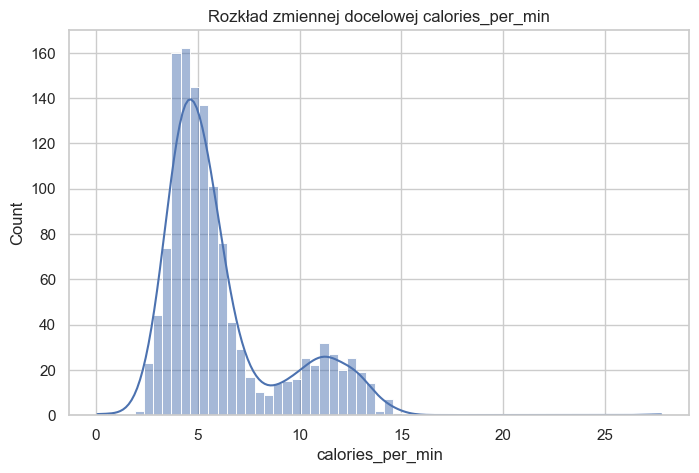

np.float64(1.48945634413599)

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['calories_per_min'], kde=True)
plt.title('Rozkład zmiennej docelowej calories_per_min')
plt.show()

df['calories_per_min'].skew()

Rozkład zmiennej `calories_per_min` jest prawostronnie skośny, z koncentracją obserwacji wokół wartości ok. 5 kcal/min oraz obecnością obserwacji odstających, odpowiadających intensywnym sesjom treningowym.

Zmienna została pozostawiona w oryginalnej skali ze względu na jej interpretowalność. Potencjalne nieliniowości mogą zostać uchwycone przez modele nieliniowe, dlatego zrezygnowano z transformacji logarytmicznej.

## Intensywność vs typ aktywności

Aby ocenić zależność pomiędzy intensywnością treningu a typem aktywności, wykorzystano wykres pudełkowy przedstawiający rozkład wskaźnika `calories_per_min` w poszczególnych kategoriach. 

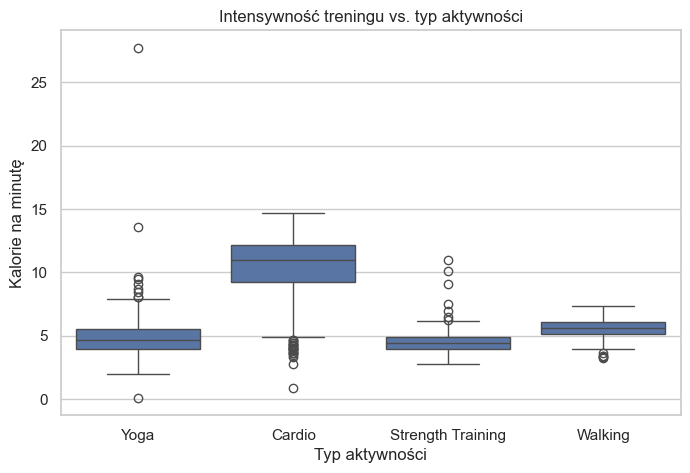

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Activity Type', y='calories_per_min')
plt.title('Intensywność treningu vs. typ aktywności')
plt.xlabel('Typ aktywności')
plt.ylabel('Kalorie na minutę')
plt.show()

Zaobserwowano istotne różnice w poziomie oraz rozrzucie intensywności pomiędzy typami aktywności. Jednocześnie częściowe nakładanie się rozkładów wskazuje, że typ aktywności nie determinuje intensywności jednoznacznie, co uzasadnia uwzględnienie dodatkowych cech w modelowaniu.

## HR vs intensywność

W kolejnym kroku przeanalizowano zależność pomiędzy średnim tętnem a intensywnością treningu, z rozróżnieniem na typ aktywności.

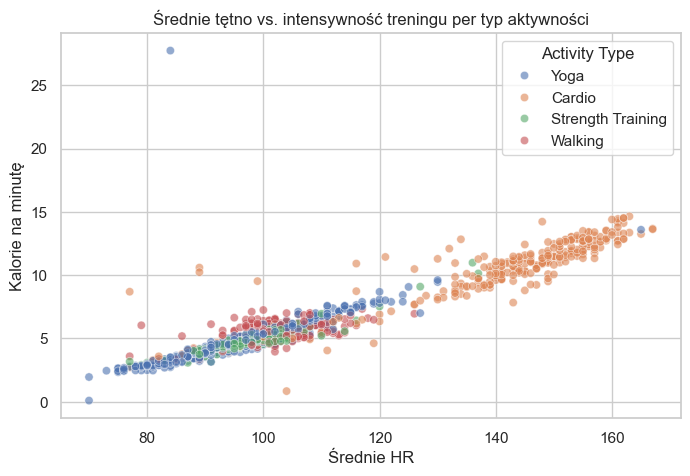

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Avg HR',
    y='calories_per_min',
    hue='Activity Type',
    alpha=0.6
)
plt.title('Średnie tętno vs. intensywność treningu per typ aktywności')
plt.xlabel('Średnie HR')
plt.ylabel('Kalorie na minutę')
plt.show()

Zaobserwowano dodatnią zależność pomiędzy średnim tętnem a intensywnością treningu, przy czym charakter relacji różni się pomiędzy typami aktywności. Częściowe nakładanie się rozkładów potwierdza zasadność podejścia regresyjnego i wyklucza trywialne mapowanie typu aktywności na poziom intensywności.

## Yoga: stres a intensywność treningu

Zmienne `Avg Stress` oraz `Stress Change` są cechami specyficznymi dla aktywności typu joga i opisują fizjologiczny poziom obciążenia organizmu. W tej części analizy zbadano ich relację z intensywnością treningu.

In [16]:
df_yoga = df[df['Activity Type'] == 'Yoga']

### Avg Stress vs intensywność treningu

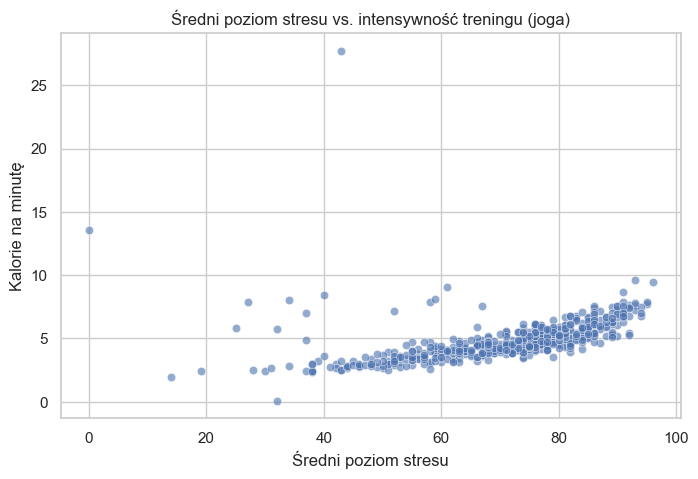

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_yoga,
    x='Avg Stress',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Średni poziom stresu vs. intensywność treningu (joga)')
plt.xlabel('Średni poziom stresu')
plt.ylabel('Kalorie na minutę')
plt.show()

### Stress Change vs intensywność treningu

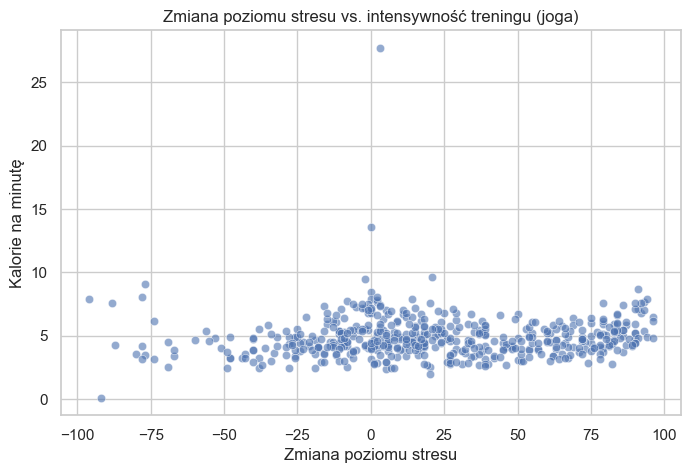

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_yoga,
    x='Stress Change',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Zmiana poziomu stresu vs. intensywność treningu (joga)')
plt.xlabel('Zmiana poziomu stresu')
plt.ylabel('Kalorie na minutę')
plt.show()

Zmienne `Avg Stress` oraz `Stress Change`, charakterystyczne dla jogi, wykazują jedynie słabą i rozproszoną zależność z intensywnością treningu. Może to sugerować nieliniowy lub kontekstowy charakter ich wpływu.

## Gym: objętość treningu a intensywność

Zmienne `Total Reps` oraz `Total Poses` opisują objętość treningu siłowego i występują wyłącznie dla aktywności typu strength training.

In [19]:
df_gym = df[df['Activity Type'] == 'Strength Training']

### Total Reps vs intensywność treningu

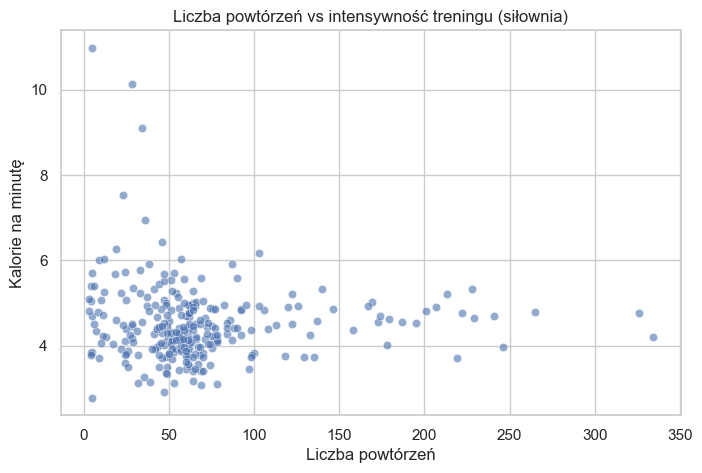

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_gym,
    x='Total Reps',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Liczba powtórzeń vs intensywność treningu (siłownia)')
plt.xlabel('Liczba powtórzeń')
plt.ylabel('Kalorie na minutę')
plt.show()

### Total Poses vs intensywność treningu

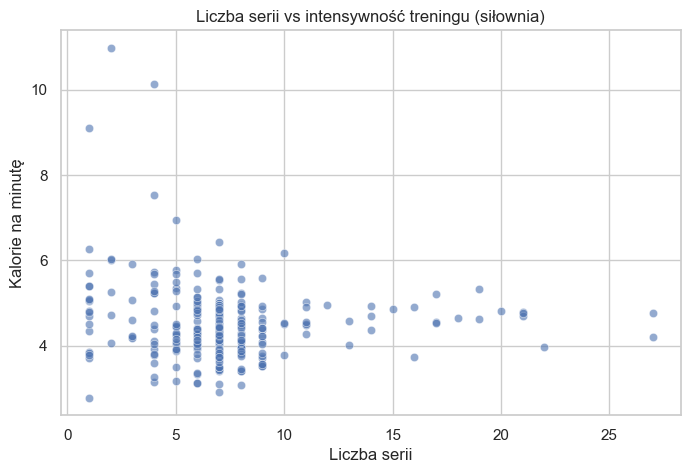

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_gym,
    x='Total Poses',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Liczba serii vs intensywność treningu (siłownia)')
plt.xlabel('Liczba serii')
plt.ylabel('Kalorie na minutę')
plt.show()

W przypadku siłowni zaobserwowano słabą dodatnią zależność pomiędzy liczbą powtórzeń (`Total Reps`) i ilością serii (`Total Poses`) a intensywnością treningu.

## Walking: dystans i liczba kroków a intensywność treningu

Zmienne `Distance` oraz `Steps` są charakterystyczne dla chodzenia i opisują objętość ruchu.

In [22]:
df_walking = df[df['Activity Type'] == 'Walking']

### Steps vs intensywność treningu

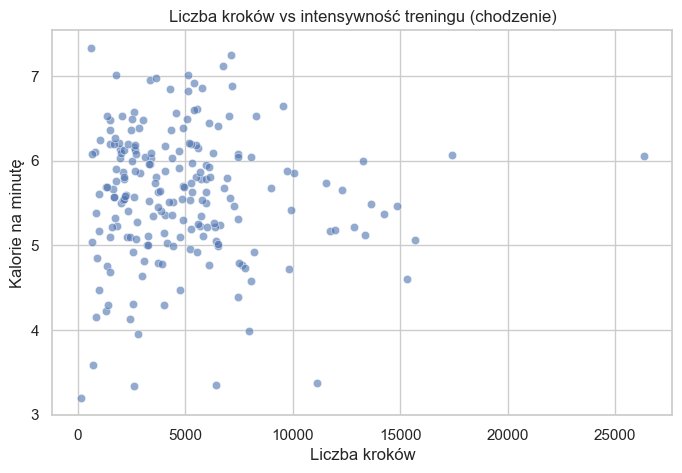

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_walking,
    x='Steps',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Liczba kroków vs intensywność treningu (chodzenie)')
plt.xlabel('Liczba kroków')
plt.ylabel('Kalorie na minutę')
plt.show()

### Distance vs intensywność treningu

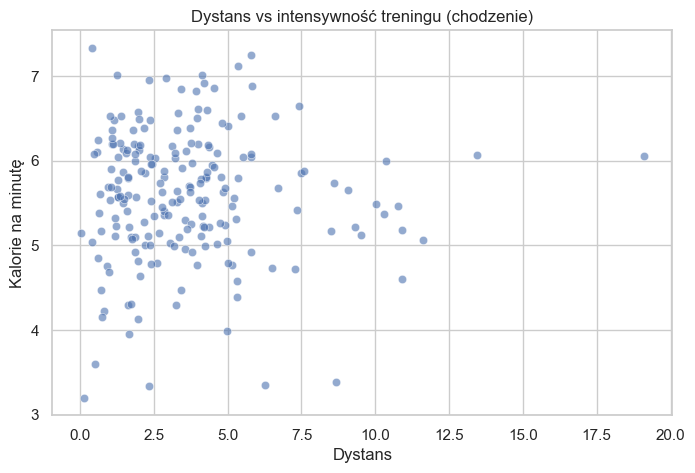

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_walking,
    x='Distance',
    y='calories_per_min',
    alpha=0.6
)
plt.title('Dystans vs intensywność treningu (chodzenie)')
plt.xlabel('Dystans')
plt.ylabel('Kalorie na minutę')
plt.show()

Analiza aktywności typu chodzenie wskazuje, że intensywność treningu nie jest determinowana wyłącznie przez dystans lub liczbę kroków, co sugeruje istotną rolę tempa oraz indywidualnych cech fizjologicznych.

## Podsumowanie 

Analizy specyficzne dla typów aktywności wskazują, że cechy objętościowe (dystans, liczba powtórzeń, liczba kroków) mogą być pomocne, lecz niewystarczające do wyjaśnienia intensywności. Najsilniejsze zależności obserwowane są dla parametrów fizjologicznych, zwłaszcza tętna. Cechy stresowe i objętościowe wykazują słabe lub nieliniowe relacje, a cechy czasowe pełnią funkcję kontekstową. Uzasadnia to włączenie parametrów fizjologicznych oraz cech kontekstowych do dalszego modelowania.

# Analiza wartości odstających

Boxplot ujawnia obecność pojedynczych obserwacji o bardzo wysokiej intensywności (powyżej 25 kcal/min). Wartości te stanowią skrajne obserwacje względem rozkładu zmiennej docelowej i znacząco odbiegają od pozostałych sesji treningowych.

Z uwagi na ich marginalną liczność oraz potencjalny wpływ destabilizujący modele regresyjne, obserwacje o intensywności powyżej 22 kcal/min zostały usunięte ze zbioru danych przed dalszym modelowaniem.

<Axes: xlabel='calories_per_min'>

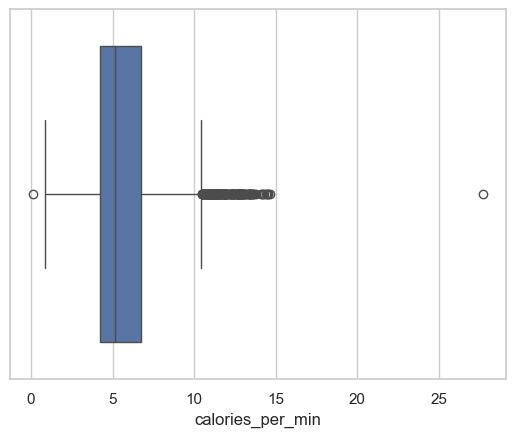

In [25]:
sns.boxplot(x=df['calories_per_min'])

In [26]:
# liczba obserwacji przed filtracją
before = df.shape[0]

# Usunięcie nierealistycznych wartości intensywności 
df = df[df['calories_per_min'] <= 22].copy()

# W celu oceny wpływu filtracji wartości odstających obliczono liczbę obserwacji usuniętych na podstawie progu fizjologicznego 22 kcal/min.
after = df.shape[0]

removed = before - after
removed, removed / before 

# Usunięto jedynie 2 obserwacje (0,16% zbioru), 
# co wskazuje, że filtracja była konserwatywna i nie wpłynęła istotnie na reprezentatywność danych.

(2, 0.0015710919088766694)

## Ilościowa analiza zależności – korelacja rang Spearmana
W celu oceny siły oraz kierunku zależności pomiędzy zmiennymi numerycznymi a intensywnością treningu obliczono współczynniki korelacji rang Spearmana. Metoda ta jest mniej wrażliwa na wartości odstające i pozwala uchwycić monotoniczne, także nieliniowe zależności. 

Analizę przeprowadzono wyłącznie na zmiennych numerycznych, po wcześniejszej konwersji kolumn tekstowych do typu `float`. Poniżej przedstawiono uporządkowane wartości korelacji względem zmiennej docelowej `calories_per_min`.

In [27]:
# Korelacja rang Spearmana dla zmiennych numerycznych
cols_for_corr = df.select_dtypes(include=['float64', 'int64', 'int32']).columns 
cols_for_corr = cols_for_corr.drop(['Calories', 'Time']) 
corr = df[cols_for_corr].corr(method='spearman') 

corr['calories_per_min'].sort_values(ascending=False)

calories_per_min    1.000000
Avg HR              0.943437
Avg Stress          0.771649
Max HR              0.636877
Steps               0.498441
hour_cos            0.224714
Stress Change       0.118775
Distance           -0.034473
Total Reps         -0.038646
day_of_week        -0.056212
Total Poses        -0.094636
hour_sin           -0.292534
Name: calories_per_min, dtype: float64

**Podsumowanie**

Najsilniejszą monotoniczną zależność z intensywnością treningu wykazuje średnie tętno (*Spearman ≈ 0.94*), co potwierdza jego kluczową rolę jako predyktora wydatku energetycznego. Wysokie korelacje obserwowane są również dla `Avg Stress` i `Max HR`. 

Cechy objętościowe oraz czasowe wykazują słabsze zależności, co wskazuje, że intensywność jest przede wszystkim determinowana parametrami fizjologicznymi. Niższe korelacje zmiennych specyficznych dla poszczególnych aktywności wynikają z ich ograniczonej dostępności w całym zbiorze.

# Podsumowanie eksploracyjnej analizy danych

Przeprowadzona analiza wykazała istotne różnice w intensywności treningu pomiędzy typami aktywności oraz wyraźne zależności pomiędzy parametrami fizjologicznymi (zwłaszcza średnim tętnem) a intensywnością wysiłku.

Zmienne specyficzne dla poszczególnych aktywności nie wykazały silnych zależności liniowych, lecz ujawniły zróżnicowanie rozkładów i potencjalne relacje nieliniowe, które mogą zostać uchwycone przez modele drzewiaste.

Na tej podstawie wyselekcjonowano zestaw cech do dalszego modelowania, którego kolejny etap obejmuje przygotowanie danych oraz budowę modeli predykcyjnych.

# Przygotowanie zbioru danych do modelowania

Ostateczny zbiór danych (`df_model`) zawiera wyłącznie te cechy, które mogą zostać wykorzystane jako predyktory w procesie uczenia maszynowego oraz zmienną docelową `calories_per_min`. Na tym etapie dane są w pełni przygotowane do budowy i ewaluacji modeli predykcyjnych.

In [28]:
# Surowe znaczniki czasu zostały wcześniej przetworzone do cech czasowych, dlatego kolumna 'Date' nie jest już potrzebna
df_model = df.drop(columns=['Date'])

# Kolumny 'Calories' oraz 'Time' zostały użyte do obliczenia zmiennej docelowej i ich pozostawienie prowadziłoby do wycieku informacji (data leakage)
df_model = df_model.drop(columns=['Calories', 'Time'])

# Ujednolicenie braków danych: zamiana symbolicznych wartości Garmina '--' na NaN
df_model = df_model.replace('--', np.nan)

# Zachowanie zmiennych specyficznych wyłącznie dla odpowiednich aktywności. 
# W pozostałych przypadkach wartości zastąpiono NaN, aby ograniczyć szum informacyjny.
df_model.loc[df_model['Activity Type'] != 'Yoga', ['Stress Change', 'Avg Stress']] = np.nan # zmienne specyficzne dla jogi
df_model.loc[df_model['Activity Type'] != 'Strength Training', ['Total Reps', 'Total Poses']] = np.nan # zmienne specyficzne dla treningu siłowego
df_model.loc[df_model['Activity Type'] != 'Walking', ['Distance', 'Steps']] = np.nan # zmienne specyficzne dla chodzenia

In [29]:
# Kontrola liczby brakujących wartości w poszczególnych kolumnach
df_model.isna().sum().sort_values(ascending=False)

Steps               1068
Distance            1067
Total Reps           999
Total Poses          999
Stress Change        769
Avg Stress           769
Max HR                 0
Activity Type          0
Avg HR                 0
day_of_week            0
hour_sin               0
hour_cos               0
calories_per_min       0
dtype: int64

**Interpretacja**

- `Distance`, `Steps` – dostępne wyłącznie dla aktywności typu Walking.
- `Total Reps`, `Total Poses` – charakterystyczne dla Strength Training.
- `Avg Stress`, `Stress Change` – występują tylko w Yoga.
- `Avg HR`, `Max HR`, cechy czasowe, cechy binarne – kompletne.

Braki danych mają charakter strukturalny i wynikają z faktu, że różne typy aktywności raportują różne metryki – oznaczają one, że dana cecha nie dotyczy konkretnej aktywności.

### Finalna walidacja strukturalna i semantyczna df_model

In [30]:
errors = {}

# Weryfikacja kompletności zmiennych obowiązkowych
required_non_null = [
    'Activity Type', 'Avg HR', 'Max HR',
    'day_of_week', 'hour_sin', 'hour_cos', 
    'calories_per_min'
]
errors['missing_required'] = df_model[required_non_null].isna().sum()

# Walidacja poprawności kategorii
valid_activity = ['Yoga', 'Cardio', 'Strength Training', 'Walking']
errors['invalid_activity_type'] = df_model[~df_model['Activity Type'].isin(valid_activity)]

# Kontrola zakresów wartości liczbowych
errors['invalid_hr'] = df_model[(df_model['Avg HR'] <= 0) | (df_model['Max HR'] < df_model['Avg HR'])]
errors['invalid_hour'] = df_model[ 
    (df_model['hour_sin'] < -1) | (df_model['hour_sin'] > 1) | 
    (df_model['hour_cos'] < -1) | (df_model['hour_cos'] > 1) | 
    (np.abs(df_model['hour_sin']**2 + df_model['hour_cos']**2 - 1) > 0.01) 
    ]
errors['invalid_day_of_week'] = df_model[(df_model['day_of_week'] < 0) | (df_model['day_of_week'] > 6)]

# Weryfikacja braku ujemnych wartości w cechach opisujących objętość treningową
volume_cols = ['Distance', 'Steps', 'Total Reps', 'Total Poses', 'Avg Stress']
errors['negative_values'] = df_model[(df_model[volume_cols] < 0).any(axis=1)]

# Walidacja zmiennej docelowej
errors['invalid_calories'] = df_model[df_model['calories_per_min'] <= 0]

# Kontrola duplikatów
errors['duplicates'] = df_model[df_model.duplicated()]

# Walidacja semantyczna cech specyficznych dla typów aktywności
required_features = {
    'Yoga': ['Avg Stress', 'Stress Change'],
    'Strength Training': ['Total Reps', 'Total Poses'],
    'Walking': ['Steps', 'Distance'],
    'Cardio': []  # brak cech specyficznych
}

invalid_semantic_masks = []

for activity, cols in required_features.items():
    if not cols:
        continue  # brak cech specyficznych do walidacji

    mask = (df_model['Activity Type'] == activity)
    for col in cols:
        mask &= (df_model[col] == 0.0) # cecha specyficzna ma wartość 0.0

    mask &= (df_model['calories_per_min'] > 0)
    invalid_semantic_masks.append(mask)

if invalid_semantic_masks:
    invalid_semantic_mask = np.logical_or.reduce(invalid_semantic_masks) # łączenie wielu masek w jedną
    errors['invalid_semantic'] = df_model[invalid_semantic_mask]
else:
    errors['invalid_semantic'] = pd.DataFrame()

# Podsumowanie wyników walidacji
for name, err in errors.items():
    if isinstance(err, pd.Series):
        print(f"{name}: {err.sum()}")
    else:
        print(f"{name}: {len(err)}")

missing_required: 0
invalid_activity_type: 0
invalid_hr: 0
invalid_hour: 0
invalid_day_of_week: 0
negative_values: 0
invalid_calories: 0
duplicates: 0
invalid_semantic: 1


In [31]:
# Usunięcie zidentyfikowanego artefaktu semantycznego
df_model = df_model[~invalid_semantic_mask]

W finalnej walidacji semantycznej wykryto pojedynczy rekord, w którym cechy specyficzne dla danej aktywności (np. `Avg Stress`, `Stress Change` dla jogi) przyjmowały wartość 0.0 mimo dodatniej intensywności. Uznano go za artefakt pomiarowy i usunięto przed modelowaniem.

## Strategia obsługi braków danych w modelowaniu

W modelowaniu zastosowane zostaną algorytmy drzewiaste tolerujące brakujące wartości. 

Modele te traktują brak wartości jako osobną gałąź decyzyjną, co pozwala zachować informację strukturalną wynikającą z heterogeniczności aktywności fizycznych. 

W kontekście danych pochodzących z urządzeń wearables jest to podejście najbardziej naturalne i zgodne z ich semantyką.

## Podgląd finalnego zbioru danych

In [32]:
df_model.head()

,Activity Type,Distance,Avg HR,Max HR,Steps,Total Reps,Total Poses,Stress Change,Avg Stress,day_of_week,hour_sin,hour_cos,calories_per_min
0,Yoga,NaN,92,136,NaN,NaN,NaN,-18.0,74.0,5,-9.659258e-01,0.258819,3.996920
1,Cardio,NaN,145,179,NaN,NaN,NaN,NaN,NaN,4,-8.660254e-01,-0.500000,10.354052
2,Cardio,NaN,148,196,NaN,NaN,NaN,NaN,NaN,3,-9.659258e-01,0.258819,11.142658
3,Strength Training,NaN,89,113,NaN,5.0,1.0,NaN,NaN,2,-8.660254e-01,0.500000,3.863574
4,Yoga,NaN,102,119,NaN,NaN,NaN,90.0,88.0,2,1.224647e-16,-1.000000,5.198330


Po usunięciu obserwacji z nierealistyczną intensywnością oraz pojedynczego artefaktu semantycznego finalny zbiór obejmuje **1270 obserwacji**.

In [33]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 1270 entries, 0 to 1339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Activity Type     1270 non-null   str    
 1   Distance          204 non-null    float64
 2   Avg HR            1270 non-null   int64  
 3   Max HR            1270 non-null   int64  
 4   Steps             203 non-null    float64
 5   Total Reps        272 non-null    float64
 6   Total Poses       272 non-null    float64
 7   Stress Change     501 non-null    float64
 8   Avg Stress        501 non-null    float64
 9   day_of_week       1270 non-null   int32  
 10  hour_sin          1270 non-null   float64
 11  hour_cos          1270 non-null   float64
 12  calories_per_min  1270 non-null   float64
dtypes: float64(9), int32(1), int64(2), str(1)
memory usage: 143.7 KB


Różnica w liczbie niepustych wartości `Distance` i `Steps` wynika z faktu, że Garmin nie zawsze raportuje obie metryki jednocześnie — nie świadczy to o błędzie w danych.

Zmienna kategoryczna (`Activity Type`) zostanie zakodowana metodą one‑hot encoding. Braki danych w zmiennych numerycznych pozostaną oznaczone jako `NaN` i zostaną obsłużone przez algorytmy drzewiaste.

## Finalne cechy modelu wraz z typem i opisem semantycznym

| Nazwa cechy        | Typ danych | Opis semantyczny                                                                 |
|--------------------|------------|----------------------------------------------------------------------------------|
| **Activity Type**  | kategoryczna (str) | Typ wykonywanej aktywności (Yoga, Cardio, Strength Training, Walking). |
| **Distance**       | float      | Dystans pokonany podczas aktywności Walking; brak wartości oznacza, że cecha nie dotyczy danej aktywności. |
| **Avg HR**         | int        | Średnie tętno podczas treningu; główny fizjologiczny predyktor intensywności.    |
| **Max HR**         | int        | Maksymalne tętno osiągnięte podczas sesji; informacja o szczytowym obciążeniu.   |
| **Steps**          | float      | Liczba kroków (Walking); brak wartości oznacza, że cecha nie dotyczy aktywności. |
| **Total Reps**     | float      | Liczba powtórzeń w treningu siłowym; brak wartości oznacza, że cecha nie dotyczy aktywności. |
| **Total Poses**    | float      | Liczba serii/pozycji w treningu siłowym; brak wartości oznacza, że cecha nie dotyczy aktywności. |
| **Stress Change**  | float      | Zmiana poziomu stresu (Yoga); brak wartości oznacza, że cecha nie dotyczy aktywności. |
| **Avg Stress**     | float      | Średni poziom stresu (Yoga); brak wartości oznacza, że cecha nie dotyczy aktywności.               |
| **day_of_week**    | int        | Dzień tygodnia (0–6); może odzwierciedlać rytm treningowy użytkownika.          |
| **hour_sin**       | float      | Reprezentacja cykliczna godziny (składowa sinusowa); modeluje rytm dobowy.   |
| **hour_cos**       | float      | Reprezentacja cykliczna godziny (składowa cosinusowa); uzupełnia hour_sin.   |
| **calories_per_min** | float    | Zmienna docelowa: intensywność treningu wyrażona jako wydatek energetyczny na minutę. |

# Podsumowanie

Zbiór `df_model` stanowi kompletny i zweryfikowany zestaw danych wejściowych do budowy modeli predykcyjnych.

Zapisano go w formacie Parquet, zapewniającym zachowanie typów zmiennych, kompresję i szybki odczyt:

In [34]:
df_model.to_parquet('../data/processed/activities_model_ready.parquet', index=False)